# Machine Learning Final Project - Phase 2 (Regression)

This notebook uses the same regression dataset, preprocessing logic, and split strategy from Phase 1, then extends comparison with new Phase 2 models.

## 1. Imports and Configuration

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

print('Imports loaded successfully.')

Imports loaded successfully.


## 2. Data Loading and Understanding

In [6]:
from pathlib import Path

DATA_PATH = 'regression/housing_prices.csv'
data_path = Path(DATA_PATH)

if not data_path.exists():
    alt_path = Path('housing_prices.csv')
    if alt_path.exists():
        data_path = alt_path
    else:
        raise FileNotFoundError(
            f"Could not find dataset at '{DATA_PATH}' or '{alt_path}'."
        )

df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

print('Data types:')
display(df.dtypes)

Dataset shape: 545 rows x 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6093731,13799.0,6.0,1.0,1,yes,no,no,no,no,0,no,furnished
1,6911321,14082.0,5.0,1.0,1,yes,no,yes,no,no,1,yes,semi-furnished
2,11220867,13193.0,3.0,2.0,2,yes,no,no,no,no,3,yes,semi-furnished
3,6842131,4327.0,5.0,3.0,2,yes,no,no,no,yes,1,no,furnished
4,6012988,5989.0,6.0,2.0,2,yes,no,no,no,no,2,no,furnished


Data types:


price                 int64
area                float64
bedrooms            float64
bathrooms           float64
stories               int64
mainroad             object
guestroom            object
basement             object
hotwaterheating      object
airconditioning      object
parking               int64
prefarea             object
furnishingstatus     object
dtype: object

## 3. Phase 1 Preprocessing (Reused)
Apply the same preprocessing steps used in Phase 1:
- Handle missing values
- Handle outliers
- Encode categorical variables

In [7]:
# Convert empty strings to NaN (same as Phase 1)
df = df.replace('', np.nan)
df = df.replace(' ', np.nan)

print('Missing values before handling:')
display(df.isnull().sum())

# Numerical imputation
for col in ['area', 'bedrooms', 'bathrooms', 'parking', 'stories']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

# Categorical imputation
for col in ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Outlier capping on same columns as Phase 1
for col in ['price', 'area']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)

# Binary mapping
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot for furnishing status
if 'furnishingstatus' in df.columns:
    dummies = pd.get_dummies(df['furnishingstatus'], prefix='furnishing', drop_first=True).astype(int)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop('furnishingstatus', axis=1)

# Ensure numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))

print('Missing values after preprocessing:')
display(df.isnull().sum())
print('Preprocessing complete.')

Missing values before handling:


price                0
area                16
bedrooms            11
bathrooms           20
stories              0
mainroad             0
guestroom            0
basement             0
hotwaterheating      0
airconditioning      0
parking              0
prefarea             0
furnishingstatus     0
dtype: int64

Missing values after preprocessing:


price                        0
area                         0
bedrooms                     0
bathrooms                    0
stories                      0
mainroad                     0
guestroom                    0
basement                     0
hotwaterheating              0
airconditioning              0
parking                      0
prefarea                     0
furnishing_semi-furnished    0
furnishing_unfurnished       0
dtype: int64

Preprocessing complete.


## 4. Train-Test Split and Scaling
Use the same split strategy from Phase 1 (test_size=0.2, random_state=42).

In [8]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (436, 13), Test shape: (109, 13)


## 5. Model Training and Evaluation
Phase 2 models:
- KNN Regressor
- Support Vector Regressor

Phase 1 baseline models included in comparison:
- Linear Regression
- Decision Tree Regressor
- AdaBoost Regressor

In [9]:
def evaluate_regressor(model, model_name, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'y_pred': y_pred
    }

models = {
    'Linear Regression (Phase 1)': LinearRegression(),
    'Decision Tree Regressor (Phase 1)': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'AdaBoost Regressor (Phase 1)': AdaBoostRegressor(random_state=RANDOM_STATE),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=7),
    'Support Vector Regressor': SVR(kernel='rbf', C=50, epsilon=0.1)
}

results = []
for name, model in models.items():
    res = evaluate_regressor(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(res)

results_df = pd.DataFrame(results)
display(results_df[['Model', 'MAE', 'MSE', 'RMSE', 'R2']].sort_values(by='R2', ascending=False).round(4))

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (Phase 1),9.205291e+05,1.264712e+12,1.124594e+06,0.6678
2,AdaBoost Regressor (Phase 1),1.043500e+06,1.673092e+12,1.293480e+06,0.5606
3,KNN Regressor,1.198879e+06,2.216910e+12,1.488929e+06,0.4177
1,Decision Tree Regressor (Phase 1),1.348444e+06,3.011410e+12,1.735341e+06,0.2091
4,Support Vector Regressor,1.609363e+06,3.839408e+12,1.959441e+06,-0.0084


## 6. Prediction vs Actual Plots
Visualize prediction quality for each model.

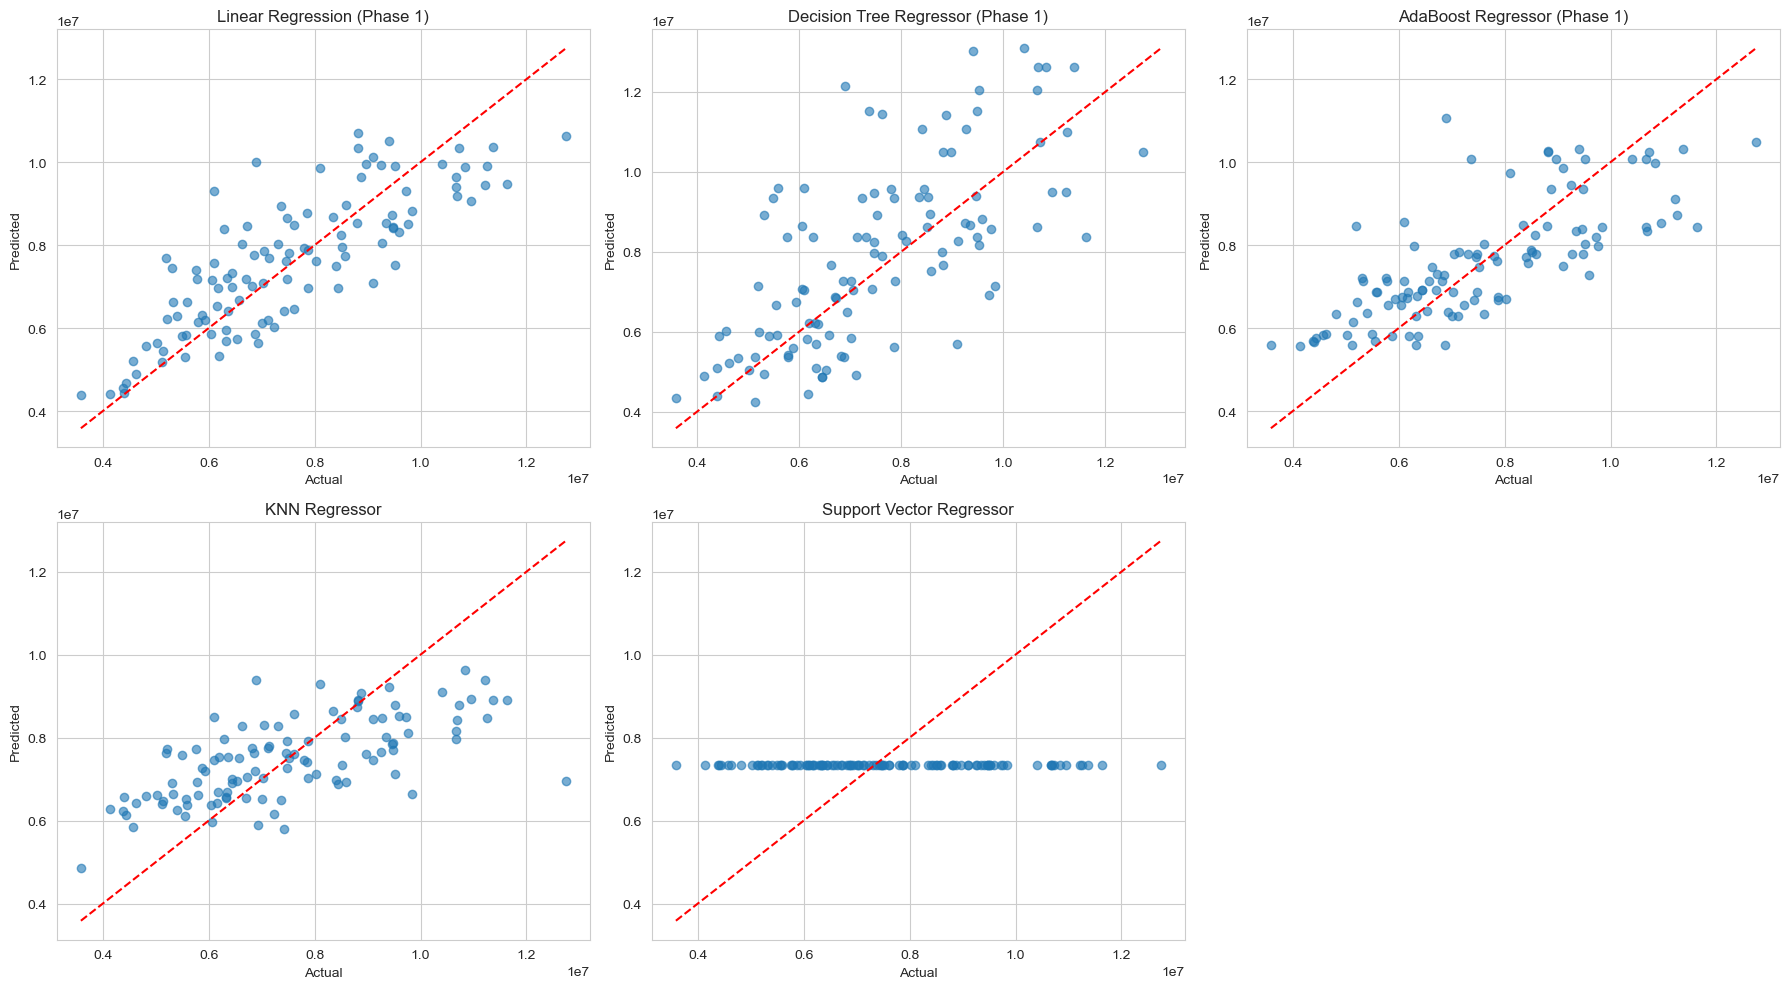

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, row in results_df.iterrows():
    ax = axes[i]
    y_pred = row['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.6)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_title(row['Model'])
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

if len(results_df) < len(axes):
    for j in range(len(results_df), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Residual Plots
Analyze residual patterns for each model.

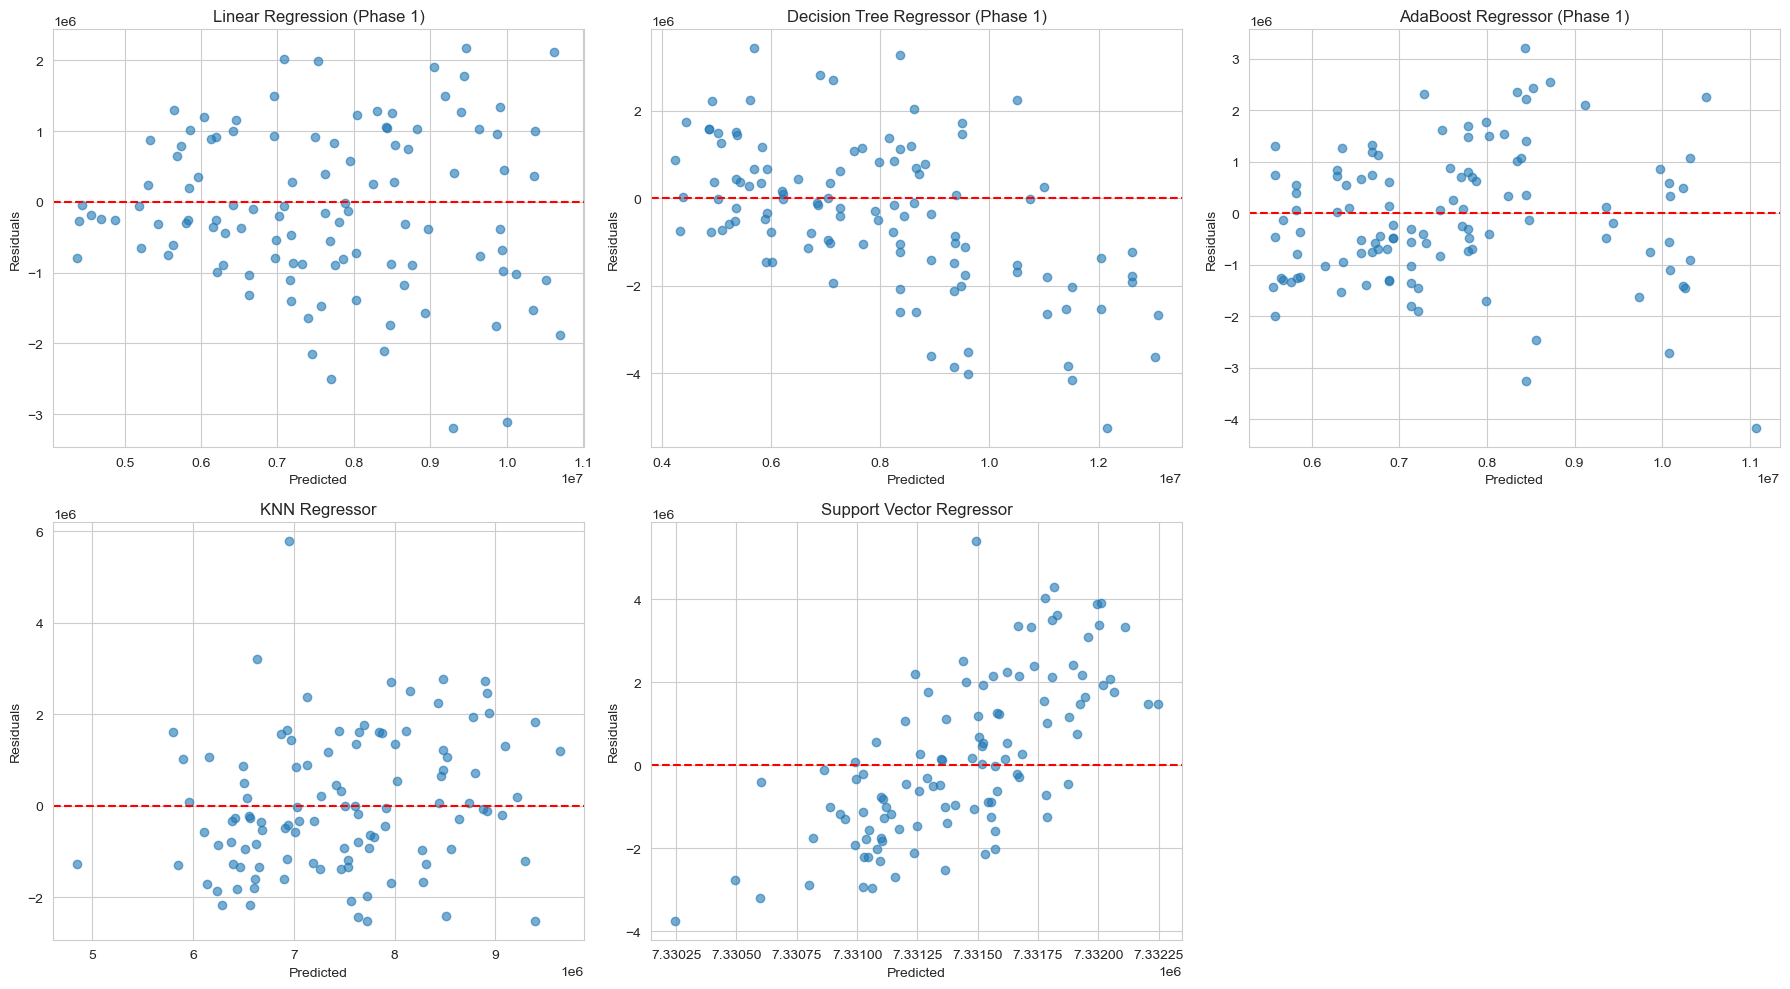

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, row in results_df.iterrows():
    ax = axes[i]
    y_pred = row['y_pred']
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6)
    ax.axhline(0, color='r', linestyle='--')
    ax.set_title(row['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residuals')

if len(results_df) < len(axes):
    for j in range(len(results_df), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Final Regression Comparison Table
Required table with MAE, MSE, RMSE, and R2 score.

In [12]:
final_regression_table = results_df[['Model', 'MAE', 'MSE', 'RMSE', 'R2']].copy()
final_regression_table = final_regression_table.sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)
display(final_regression_table.round(4))

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (Phase 1),9.205291e+05,1.264712e+12,1.124594e+06,0.6678
1,AdaBoost Regressor (Phase 1),1.043500e+06,1.673092e+12,1.293480e+06,0.5606
2,KNN Regressor,1.198879e+06,2.216910e+12,1.488929e+06,0.4177
3,Decision Tree Regressor (Phase 1),1.348444e+06,3.011410e+12,1.735341e+06,0.2091
4,Support Vector Regressor,1.609363e+06,3.839408e+12,1.959441e+06,-0.0084


## 9. Best Model and Conclusion
Select the best model using high R2 and low error metrics (especially RMSE and MAE).

In [13]:
best_row = final_regression_table.iloc[0]

print('Best Regression Model:')
print(f"Model: {best_row['Model']}")
print(f"R2: {best_row['R2']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")
print(f"MAE: {best_row['MAE']:.4f}")

print('\nConclusion:')
print('This model is selected because it provides the strongest explanatory power (high R2)')
print('while keeping prediction errors (MAE and RMSE) lower than other models.')

Best Regression Model:
Model: Linear Regression (Phase 1)
R2: 0.6678
RMSE: 1124593.9380
MAE: 920529.0673

Conclusion:
This model is selected because it provides the strongest explanatory power (high R2)
while keeping prediction errors (MAE and RMSE) lower than other models.
